<a href="https://colab.research.google.com/github/albertbolanoss/labs_deep_learning/blob/main/notebooks/handwritten-digits/03_deep_nn_handwritten_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Tensoflow

## Load dependencies

In [24]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

## Load data

In [25]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [26]:

print(f"X train shape: {X_train.shape}")
print(f"Y train shape: {y_train.shape}")
print(f"X test shape: {X_test.shape}")
print(f"Y test shape: {y_test.shape}")

X train shape: (60000, 28, 28)
Y train shape: (60000,)
X test shape: (10000, 28, 28)
Y test shape: (10000,)


## Visualize data

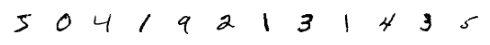

In [27]:
plt.figure(figsize=(5,5))
for k in range(12):
    plt.subplot(1,12,k+1)
    plt.imshow(X_train[k], cmap="Greys")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [28]:
y_train[0:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

In [29]:
X_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

## Pre procesing

In [30]:
X_train = X_train.reshape(60000, 28, 28, 1).astype("float32")
X_test = X_test.reshape(10000, 28, 28, 1).astype("float32")

X_train /=255
X_test  /=255

X_train[0]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [31]:
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

y_train[0]


array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

## Design Neuron Network Architecture

In [32]:
model = Sequential()

# First hidden layer
            # Neurons / Kernel or filter size 
model.add(Conv2D(32, kernel_size=(3, 3), strides=(1, 1), activation="relu", input_shape=(28, 28, 1)))

# Second hidden layer
model.add(Conv2D(64, kernel_size=(3, 3), strides=(1, 1), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())

# Third hidden layer
model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())  # Normalize the outputs to avoid Neuron Saturation
model.add(Dropout(0.5))

# output layer
model.add(Dense(10, activation="softmax"))

model.summary()

c:\Development\repositories\labs_deep_learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,394 (4.58 MB)

 Trainable params: 1,200,138 (4.58 MB)

 Non-trainable params: 256 (1.00 KB)

## Compile model

In [33]:
model.compile(loss="categorical_crossentropy", optimizer='nadam', metrics=['accuracy'])


## Callbacks

In [34]:
# 1. Early Stopping: Detiene el entrenamiento si el val_loss no mejora en 10 épocas seguidas
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=10,             # Cuántas épocas esperar sin mejora antes de detener
    restore_best_weights=True, # Restaura los pesos de la mejor época (¡Súper importante!)
    verbose=1
)


# 2. Local checkpoint
local_checkpoint = ModelCheckpoint(
    filepath='/content/digits.keras',
    monitor='val_loss',
    save_best_only=True
)


## Train

In [35]:
model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    verbose=True,
    validation_data=(X_test, y_test),
    callbacks=[early_stopper, local_checkpoint]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9552 - loss: 0.1543 - val_accuracy: 0.9780 - val_loss: 0.0725
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9808 - loss: 0.0636 - val_accuracy: 0.9888 - val_loss: 0.0369
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9861 - loss: 0.0464 - val_accuracy: 0.9881 - val_loss: 0.0365
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9879 - loss: 0.0381 - val_accuracy: 0.9889 - val_loss: 0.0348
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9897 - loss: 0.0333 - val_accuracy: 0.9894 - val_loss: 0.0341
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9913 - loss: 0.0279 - val_accuracy: 0.9911 - val_loss: 0.0287
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9921 - loss: 0.0247 - val_accuracy: 0.9908 - val_loss: 0.0317
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9929 - loss: 0.0213 - 

## Evaluate Model

In [36]:
model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0281


[0.028103647753596306, 0.9919999837875366]

## Model Save and load

In [38]:
output_model_path = "../../models/digits.keras"

model.save(output_model_path)

loaded_model = tf.keras.models.load_model(output_model_path)

## Inference

In [40]:
import numpy as np

# Forma: (Batch, Alto, Ancho, Canales)
data = X_test[0].reshape(1, 28, 28, 1) 

probabilidades = loaded_model.predict(data)
clases_predichas = np.argmax(probabilidades, axis=-1)
print(clases_predichas)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[7]


## Checking data

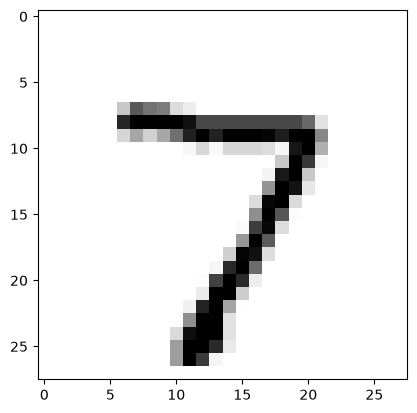

In [41]:
plt.imshow(X_test[0].reshape(28, 28), cmap="Greys")
